# 🚢 Feature Engineering on the Titanic Dataset

**Feature engineering** is the process of creating, transforming, or selecting input variables from raw data to improve a machine learning model's performance.  
The Titanic dataset is a classic playground for practicing these techniques because it contains a rich mix of numeric, categorical, and missing-heavy columns.

> **Data source:** `seaborn.load_dataset("titanic")` — no CSV needed.

---

## 📋 Table of Contents

| # | Section | Technique |
|---|---------|-----------|
| 1 | Setup & Load | `seaborn.load_dataset` |
| 2 | Data Dictionary | Column definitions |
| 3 | EDA | Shape, dtypes, missing values, distributions |
| 4 | Missing Value Handling | Median / mode imputation, missing-as-information |
| 5 | Domain-Knowledge Features | Family size, is_alone, family group |
| 6 | Title / Social Status Feature | Derived from sex + who + pclass |
| 7 | Binning | Age groups (uniform), fare groups (quantile) |
| 8 | Boolean / Rule-Based | is_child, is_female, is_first_class, is_high_fare |
| 9 | Numeric Transformations | Fare per person, log-fare, fare-vs-class ratio |
| 10 | Interaction Features | sex × class, age × class |
| 11 | Encoding | One-hot, ordinal, binary mapping |
| 12 | Correlation Analysis | Which features predict survival? |
| 13 | Final Summary | Complete engineered DataFrame |

---


## 1. 📦 Imports & Global Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})

print("Libraries loaded ✅")


Libraries loaded ✅


## 2. 📂 Load the Titanic Dataset

`seaborn.load_dataset("titanic")` returns 891 rows and 15 columns.  
It is Kaggle's training split with several pre-processed helper columns added by seaborn.


In [2]:
df_raw = sns.load_dataset("titanic")
df = df_raw.copy()

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 3. 📖 Data Dictionary

| Column | Type | Meaning |
|--------|------|---------|
| `survived` | int | **Target** — 0 = Died, 1 = Survived |
| `pclass` | int | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `sex` | str | Gender |
| `age` | float | Age in years (177 NaN) |
| `sibsp` | int | # siblings / spouses aboard |
| `parch` | int | # parents / children aboard |
| `fare` | float | Ticket price |
| `embarked` | str | Port: C = Cherbourg, Q = Queenstown, S = Southampton |
| `class` | cat | Text label for pclass |
| `who` | str | "man", "woman", or "child" |
| `adult_male` | bool | True if adult male |
| `deck` | cat | Deck letter (688 NaN — 77% missing) |
| `embark_town` | str | Full embarkation town name |
| `alive` | str | String version of survived |
| `alone` | bool | True if traveling alone |

> Seaborn's version does **not** include `name` or `ticket`.  
> We will derive title/social-status proxies from `who`, `sex`, and `pclass`.


## 4. 🔍 Exploratory Data Analysis

In [3]:
print("── dtypes ──")
print(df.dtypes)
print()
print("── Missing Values ──")
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
print(pd.DataFrame({"count": miss, "pct%": miss_pct})[miss > 0])


── dtypes ──
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

── Missing Values ──
             count  pct%
age            177  19.9
embarked         2   0.2
deck           688  77.2
embark_town      2   0.2


In [4]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\293049189.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", palette="Set1", ax=axes[1])
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\293049189.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", palette="Blues_r", ax=axes[2])


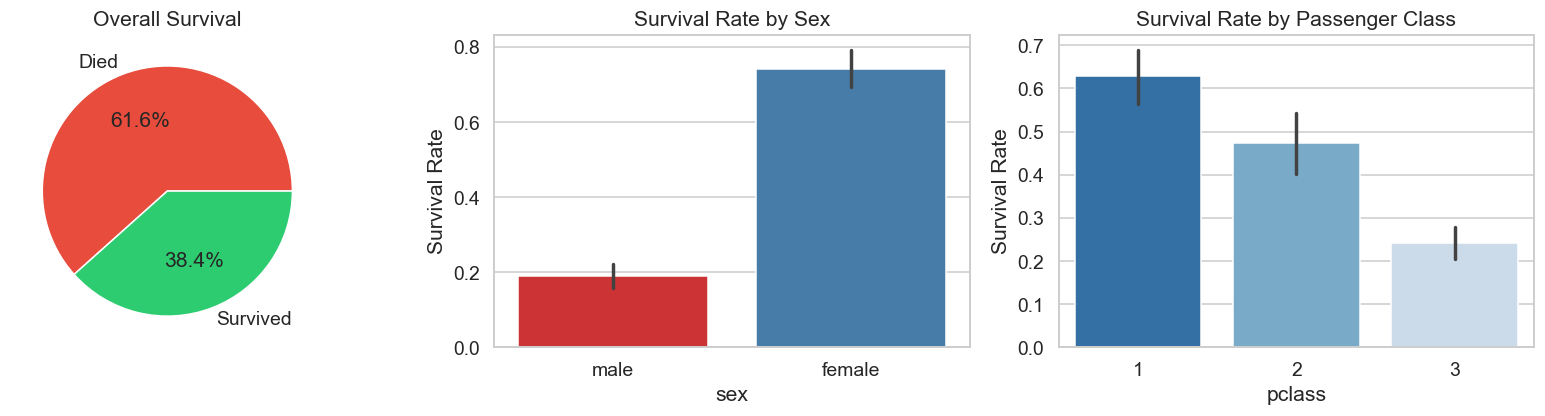

In [5]:
# Survival overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["survived"].value_counts().plot.pie(
    labels=["Died", "Survived"], autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"], ax=axes[0]
)
axes[0].set_title("Overall Survival")
axes[0].set_ylabel("")

sns.barplot(data=df, x="sex", y="survived", palette="Set1", ax=axes[1])
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Survival Rate")

sns.barplot(data=df, x="pclass", y="survived", palette="Blues_r", ax=axes[2])
axes[2].set_title("Survival Rate by Passenger Class")
axes[2].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\79294230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sibsp", palette="Purples", ax=axes[1][0])
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\79294230.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="parch", palette="Greens", ax=axes[1][1])


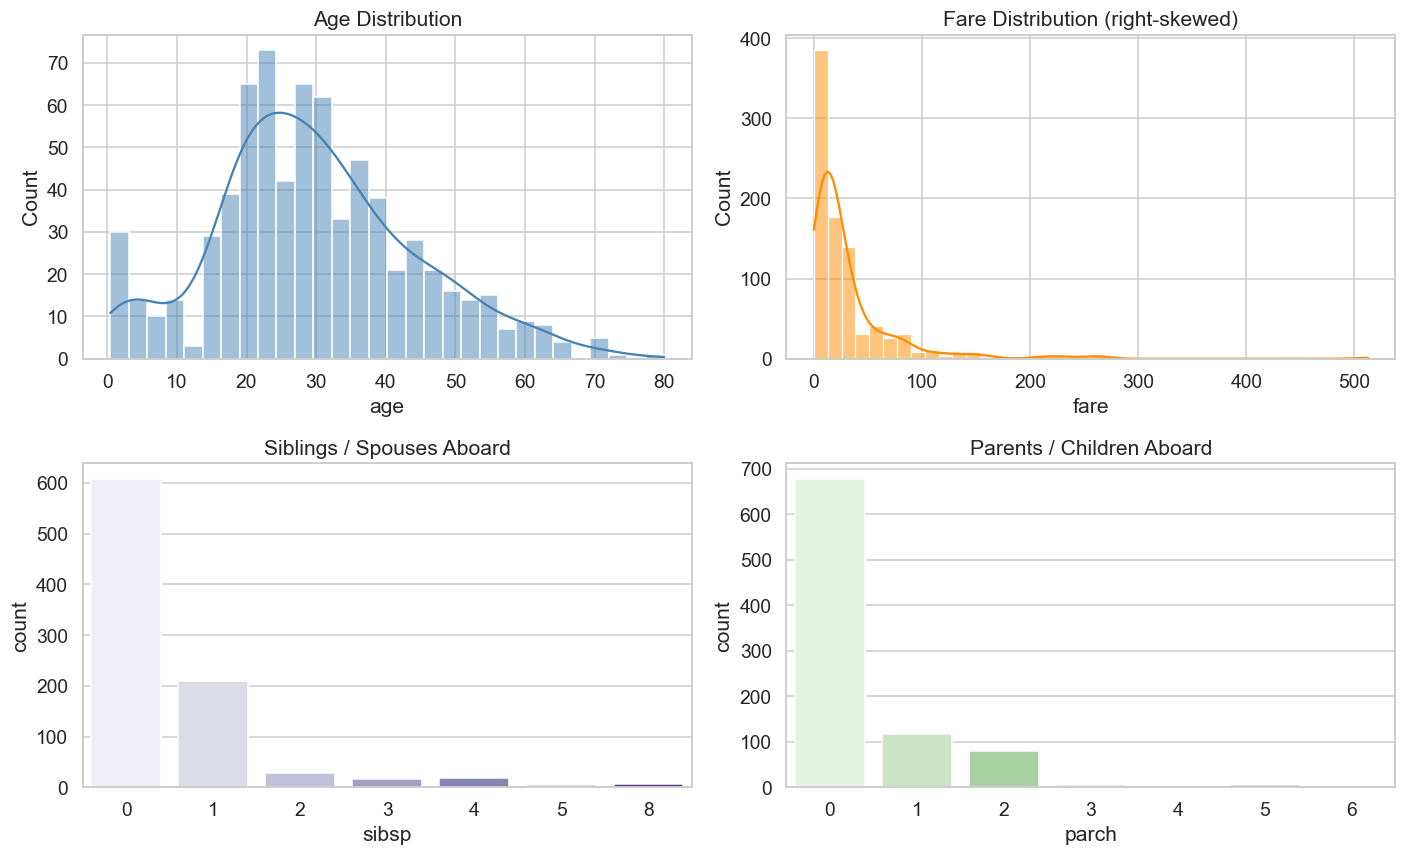

In [6]:
# Numeric distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df["age"].dropna(), kde=True, bins=30, ax=axes[0][0], color="steelblue")
axes[0][0].set_title("Age Distribution")

sns.histplot(df["fare"].dropna(), kde=True, bins=40, ax=axes[0][1], color="darkorange")
axes[0][1].set_title("Fare Distribution (right-skewed)")

sns.countplot(data=df, x="sibsp", palette="Purples", ax=axes[1][0])
axes[1][0].set_title("Siblings / Spouses Aboard")

sns.countplot(data=df, x="parch", palette="Greens", ax=axes[1][1])
axes[1][1].set_title("Parents / Children Aboard")

plt.tight_layout()
plt.show()


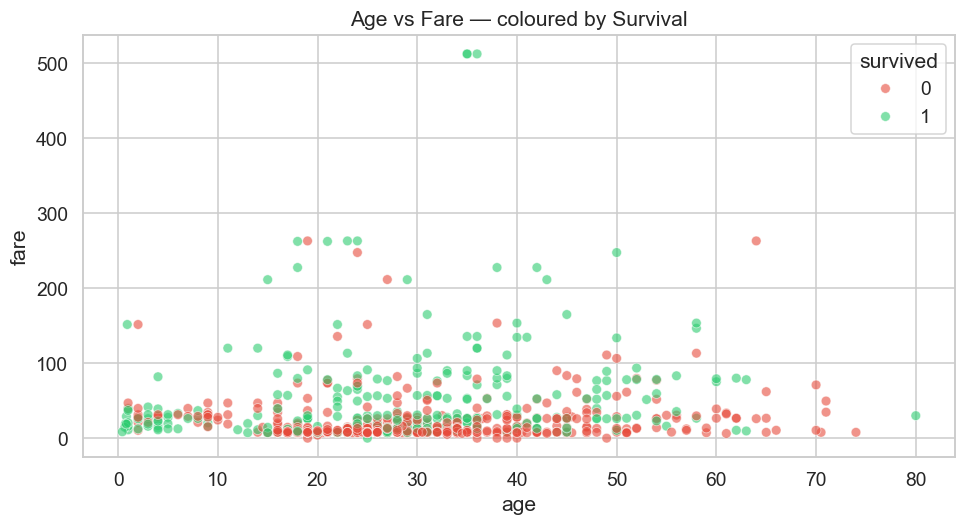

In [7]:
# Age vs Fare coloured by survival
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived",
                palette={0: "#e74c3c", 1: "#2ecc71"}, alpha=0.6, s=40)
plt.title("Age vs Fare — coloured by Survival")
plt.tight_layout()
plt.show()


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\2524468085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="embarked", y="survived",


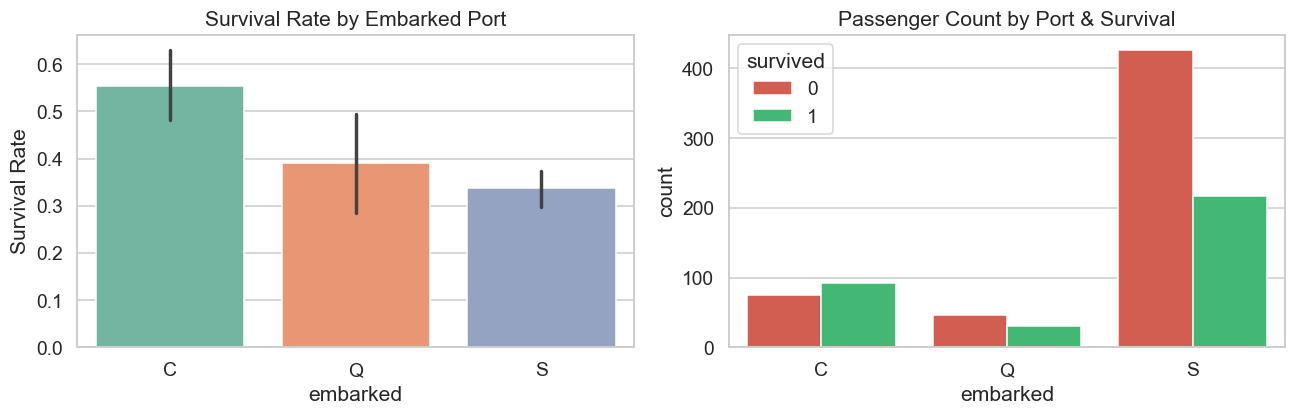

In [8]:
# Survival rate by embarkation port
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="embarked", y="survived",
            order=["C", "Q", "S"], palette="Set2", ax=axes[0])
axes[0].set_title("Survival Rate by Embarked Port")
axes[0].set_ylabel("Survival Rate")

sns.countplot(data=df, x="embarked", order=["C", "Q", "S"],
              hue="survived", palette={0:"#e74c3c", 1:"#2ecc71"}, ax=axes[1])
axes[1].set_title("Passenger Count by Port & Survival")

plt.tight_layout()
plt.show()


## 5. 🧹 Handle Missing Values

| Column | Missing | Strategy |
|--------|---------|----------|
| `age` | 177 (19.9%) | Median imputation |
| `embarked` | 2 (0.2%) | Mode imputation |
| `deck` | 688 (77.2%) | Extract `has_cabin` flag, then drop |
| `embark_town` | 2 (0.2%) | Duplicate of `embarked` — drop |

> **Key insight:** Missing `deck` is informative — lower-class passengers rarely had assigned cabins.


In [9]:
# ── has_cabin: extract signal before dropping deck ──
df["has_cabin"] = df["deck"].notna().astype(int)
print("has_cabin value counts:")
print(df["has_cabin"].value_counts())
print()
print("Survival rate by has_cabin:")
print(df.groupby("has_cabin")["survived"].mean().round(3))


has_cabin value counts:
has_cabin
0    688
1    203
Name: count, dtype: int64

Survival rate by has_cabin:
has_cabin
0    0.299
1    0.670
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\2851466426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="has_cabin", y="survived",


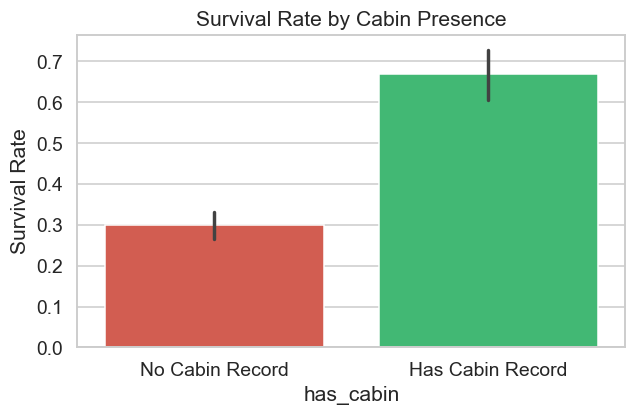

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="has_cabin", y="survived",
            palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Cabin Record", "Has Cabin Record"])
plt.title("Survival Rate by Cabin Presence")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


In [11]:
# ── Imputation ──
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)
print(f"Age: filled {df_raw['age'].isna().sum()} NaNs with median {age_median:.1f}")

mode_emb = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(mode_emb)
print(f"Embarked: filled missing with mode '{mode_emb}'")

# Drop columns we won't use
df.drop(columns=["deck", "embark_town", "alive", "class"], inplace=True)

print()
print("Missing after imputation:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.any() else "None ✅")


Age: filled 177 NaNs with median 28.0
Embarked: filled missing with mode 'S'

Missing after imputation:
None ✅


## 6. 👨‍👩‍👧 Domain-Knowledge Features

### 6a. Family Size
Passengers traveling with family behaved differently during evacuation.  
Small families had the highest survival — large groups got separated, solo travelers were deprioritised.


In [12]:
df["family_size"] = df["sibsp"] + df["parch"] + 1   # +1 = the passenger themselves

print("── Value Counts ──")
print(df["family_size"].value_counts().sort_index())
print()
print("── Survival Rate by Family Size ──")
print(df.groupby("family_size")["survived"].mean().round(3))


── Value Counts ──
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

── Survival Rate by Family Size ──
family_size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\1019628816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="family_size", palette="Blues", ax=axes[0])
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\1019628816.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=family_surv, x="family_size", y="survived",


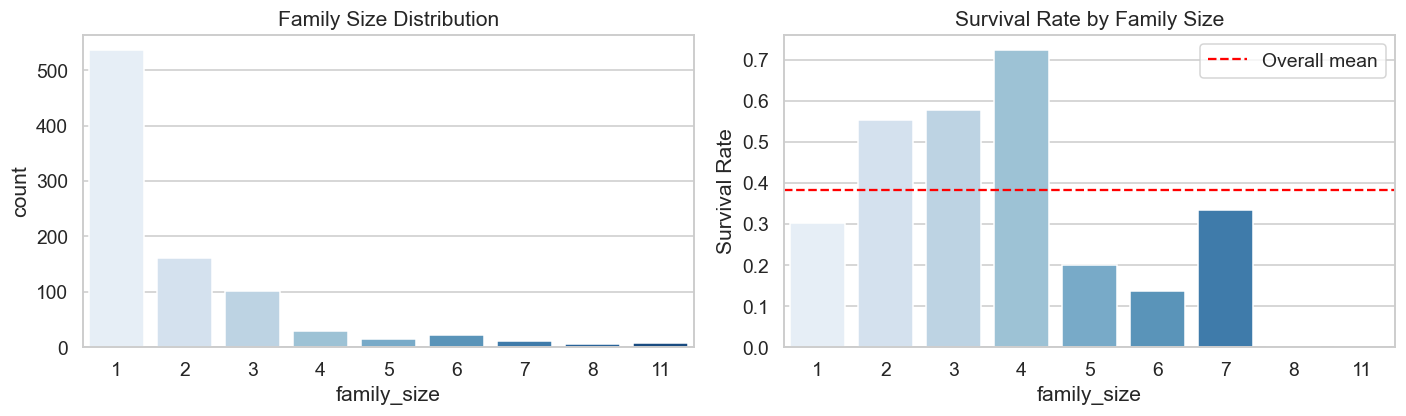

Observation: family sizes 2–4 had the best survival; solo travelers and families of 5+ fared worst.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="family_size", palette="Blues", ax=axes[0])
axes[0].set_title("Family Size Distribution")

family_surv = df.groupby("family_size")["survived"].mean().reset_index()
sns.barplot(data=family_surv, x="family_size", y="survived",
            palette="Blues", ax=axes[1])
axes[1].axhline(df["survived"].mean(), color="red", linestyle="--", label="Overall mean")
axes[1].legend()
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

print("Observation: family sizes 2–4 had the best survival; solo travelers and families of 5+ fared worst.")


### 6b. Is Alone

In [14]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

print(df["is_alone"].value_counts())
print()
print("Survival rate — alone vs not alone:")
print(df.groupby("is_alone")["survived"].mean().round(3))


is_alone
1    537
0    354
Name: count, dtype: int64

Survival rate — alone vs not alone:
is_alone
0    0.506
1    0.304
Name: survived, dtype: float64


### 6c. Family Group (Categorical)

C:\Users\hi\AppData\Local\Temp\ipykernel_22896\3493439286.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="family_group", y="survived", order=order, palette="Set2")


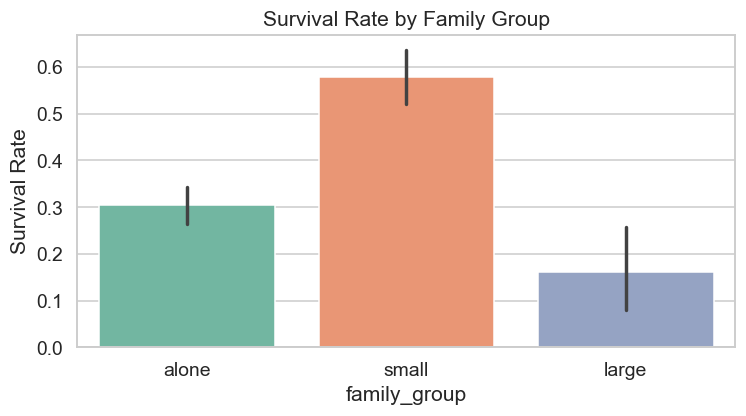

In [15]:
def family_group(n):
    if n == 1:  return "alone"
    if n <= 4:  return "small"
    return "large"

df["family_group"] = df["family_size"].apply(family_group)

order = ["alone", "small", "large"]
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="family_group", y="survived", order=order, palette="Set2")
plt.title("Survival Rate by Family Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


## 7. 🎩 Social Status Feature (Title Proxy)

The seaborn Titanic dataset does not include passenger names, so we cannot extract titles with regex.  
Instead, we **derive a social status label** from three columns we do have: `who`, `sex`, and `pclass`.

| who | pclass | → social_status |
|-----|--------|-----------------|
| child | any | Child |
| woman | 1 | Lady |
| woman | 2 or 3 | Mrs / Miss |
| man | 1 | Gentleman |
| man | 2 or 3 | Mr |


In [16]:
def social_status(row):
    if row["who"] == "child":
        return "Child"
    if row["who"] == "woman":
        return "Lady" if row["pclass"] == 1 else "Woman"
    # man
    return "Gentleman" if row["pclass"] == 1 else "Mr"

df["social_status"] = df.apply(social_status, axis=1)

print("── Value Counts ──")
print(df["social_status"].value_counts())
print()
print("── Survival Rate by Social Status ──")
print(df.groupby("social_status")["survived"].mean().sort_values(ascending=False).round(3))


── Value Counts ──
social_status
Mr           418
Woman        180
Gentleman    119
Lady          91
Child         83
Name: count, dtype: int64

── Survival Rate by Social Status ──
social_status
Lady         0.978
Woman        0.644
Child        0.590
Gentleman    0.353
Mr           0.110
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\3688102319.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="social_status", y="survived",


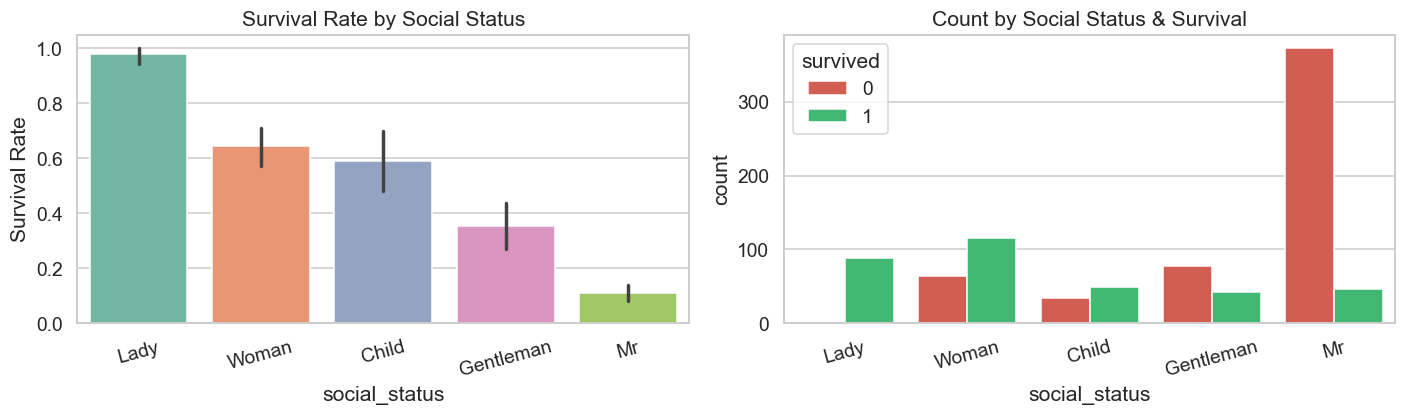

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

status_order = (df.groupby("social_status")["survived"]
                .mean().sort_values(ascending=False).index.tolist())

sns.barplot(data=df, x="social_status", y="survived",
            order=status_order, palette="Set2", ax=axes[0])
axes[0].set_title("Survival Rate by Social Status")
axes[0].set_ylabel("Survival Rate")
axes[0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="social_status", order=status_order,
              hue="survived", palette={0:"#e74c3c", 1:"#2ecc71"}, ax=axes[1])
axes[1].set_title("Count by Social Status & Survival")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


In [18]:
# Ordinal encode: rank by survival rate
status_surv = df.groupby("social_status")["survived"].mean().sort_values()
status_rank = {s: i for i, s in enumerate(status_surv.index)}
df["status_encoded"] = df["social_status"].map(status_rank)

print("Social status → encoded rank (higher = higher survival):")
print(pd.Series(status_rank))


Social status → encoded rank (higher = higher survival):
Mr           0
Gentleman    1
Child        2
Woman        3
Lady         4
dtype: int64


## 8. 📊 Binning (Discretisation)

### 8a. Age Groups — Uniform Bins


**Why?**
- Models often learn better from age categories.

```
(0, 12]   -> Child
(12, 18]  -> Teen
(18, 60]  -> Adult
(60, 100] -> Senior
```


In [19]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 60, 100],
    labels=["Child", "Teen", "Adult", "Senior"],
    include_lowest=True
)

print("── Value Counts ──")
print(df["age_group"].value_counts())
print()
print("── Survival Rate by Age Group ──")
print(df.groupby("age_group", observed=True)["survived"].mean().round(3))


── Value Counts ──
age_group
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

── Survival Rate by Age Group ──
age_group
Child     0.580
Teen      0.429
Adult     0.366
Senior    0.227
Name: survived, dtype: float64


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\2585472195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="age_group", y="survived", order=ag_order,
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\2585472195.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="age_group", y="fare", order=ag_order,


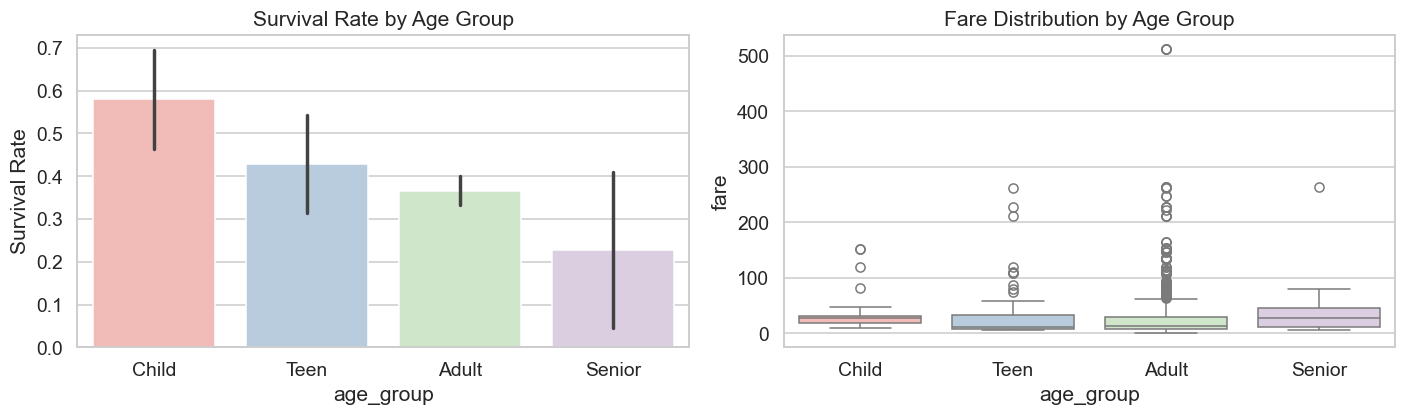

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ag_order = ["Child", "Teen", "Adult", "Senior"]

sns.barplot(data=df, x="age_group", y="survived", order=ag_order,
            palette="Pastel1", ax=axes[0])
axes[0].set_title("Survival Rate by Age Group")
axes[0].set_ylabel("Survival Rate")

sns.boxplot(data=df, x="age_group", y="fare", order=ag_order,
            palette="Pastel1", ax=axes[1])
axes[1].set_title("Fare Distribution by Age Group")

plt.tight_layout()
plt.show()


### 8b. Fare Groups — Quantile Bins (Equal-Frequency)

In [21]:
df["fare_group"] = pd.qcut(df["fare"], q=4,
                            labels=["budget", "economy", "comfort", "luxury"])

print("── Value Counts ──")
print(df["fare_group"].value_counts())
print()
print("── Survival Rate by Fare Group ──")
print(df.groupby("fare_group", observed=True)["survived"].mean().round(3))


── Value Counts ──
fare_group
economy    224
budget     223
comfort    222
luxury     222
Name: count, dtype: int64

── Survival Rate by Fare Group ──
fare_group
budget     0.197
economy    0.304
comfort    0.455
luxury     0.581
Name: survived, dtype: float64


In [ ]:
fare_order = ["budget", "economy", "comfort", "luxury"]
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="fare_group", y="survived", order=fare_order, palette="YlOrRd")
plt.title("Survival Rate by Fare Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()


## 9. ✅ Boolean / Rule-Based Features

Simple threshold rules that encode domain knowledge directly.


In [22]:
df["is_child"]       = (df["age"] < 12).astype(int)
df["is_female"]      = (df["sex"] == "female").astype(int)
df["is_first_class"] = (df["pclass"] == 1).astype(int)
df["is_high_fare"]   = (df["fare"] > df["fare"].median()).astype(int)

for col in ["is_child", "is_female", "is_first_class", "is_high_fare", "has_cabin", "is_alone"]:
    rate = df.groupby(col)["survived"].mean().round(3).to_dict()
    print(f"{col}: {rate}")


is_child: {0: 0.368, 1: 0.574}
is_female: {0: 0.189, 1: 0.742}
is_first_class: {0: 0.305, 1: 0.63}
is_high_fare: {0: 0.251, 1: 0.518}
has_cabin: {0: 0.299, 1: 0.67}
is_alone: {0: 0.506, 1: 0.304}


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=feat, y="survived",
C:\Users\hi\AppData\Local\Temp\ipykernel_22896\710396927.py:9: FutureWarning: 

Passing `palette` without assigning `hue`

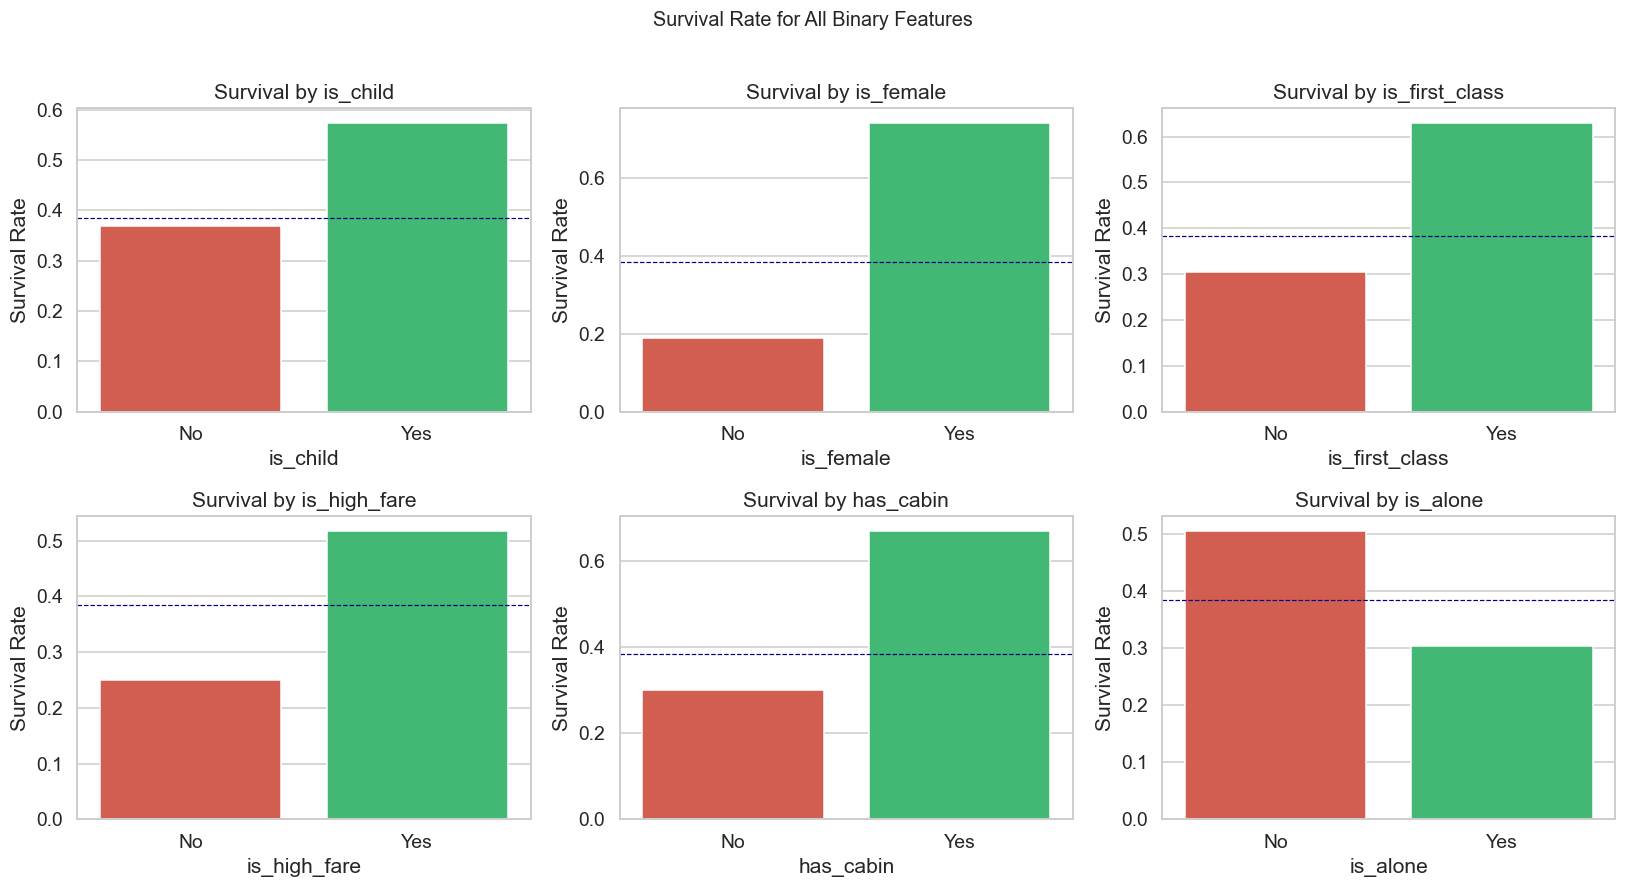

In [23]:
binary_features = ["is_child", "is_female", "is_first_class",
                   "is_high_fare", "has_cabin", "is_alone"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(binary_features):
    rate = df.groupby(feat)["survived"].mean().reset_index()
    sns.barplot(data=rate, x=feat, y="survived",
                palette=["#e74c3c", "#2ecc71"], ax=axes[i])
    axes[i].set_title(f"Survival by {feat}")
    axes[i].set_ylabel("Survival Rate")
    axes[i].axhline(df["survived"].mean(), color="navy", linestyle="--", linewidth=0.8)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])

plt.suptitle("Survival Rate for All Binary Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 10. 🔢 Numeric Transformations

### 10a. Fare per Person
Group tickets inflate the raw fare — dividing by family size makes it per-person.


In [24]:
df["fare_per_person"] = df["fare"] / df["family_size"]

print(df[["fare", "family_size", "fare_per_person"]].sample(10))


         fare  family_size  fare_per_person
535   26.2500            3         8.750000
159   69.5500           11         6.322727
739    7.8958            1         7.895800
509   56.4958            1        56.495800
367    7.2292            1         7.229200
233   31.3875            7         4.483929
345   13.0000            1        13.000000
175    7.8542            3         2.618067
50    39.6875            6         6.614583
118  247.5208            2       123.760400


### 10b. Log-Fare (Handle Skewness)

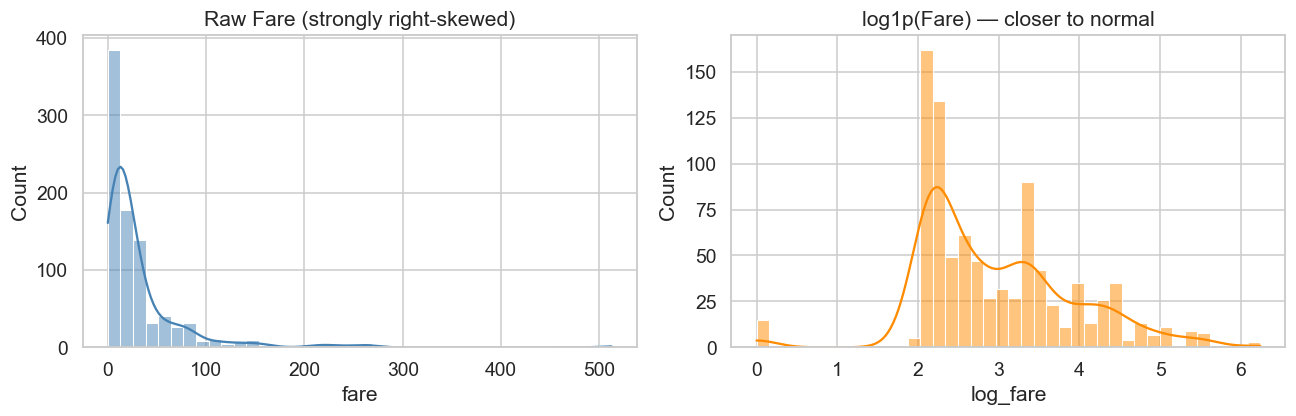

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["fare"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Raw Fare (strongly right-skewed)")

df["log_fare"] = np.log1p(df["fare"])
sns.histplot(df["log_fare"], kde=True, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("log1p(Fare) — closer to normal")

plt.tight_layout()
plt.show()


### 10c. Fare Relative to Class Median

In [ ]:
# Did this passenger pay more or less than typical for their class?
class_median = df.groupby("pclass")["fare"].transform("median")
df["fare_vs_class"] = df["fare"] / class_median

print("High value = overpaid vs class peers:")
print(df[["pclass", "fare", "fare_vs_class"]].sort_values("fare_vs_class", ascending=False).head(8))


## 11. 🔗 Interaction Features

### 11a. Sex × Class
The single most powerful predictor of Titanic survival is the combination of gender and class.


In [26]:
df["sex_class"] = df["sex"].astype(str) + "_" + df["pclass"].astype(str)

sc_surv = (df.groupby("sex_class")["survived"]
             .mean()
             .sort_values(ascending=False)
             .reset_index())
print(sc_surv)


  sex_class  survived
0  female_1  0.968085
1  female_2  0.921053
2  female_3  0.500000
3    male_1  0.368852
4    male_2  0.157407
5    male_3  0.135447


C:\Users\hi\AppData\Local\Temp\ipykernel_22896\1921869881.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sc_surv, x="sex_class", y="survived", palette="Set2")


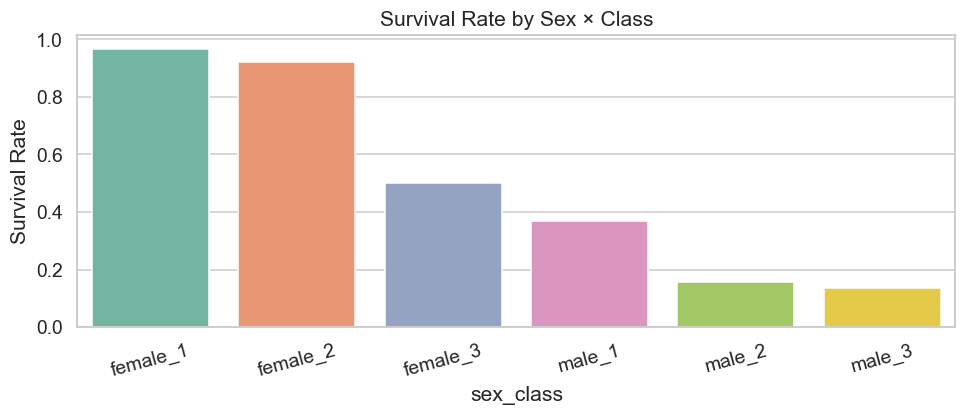

Observation: female_1 had ~97% survival; male_3 had ~13%.


In [27]:
plt.figure(figsize=(9, 4))
sns.barplot(data=sc_surv, x="sex_class", y="survived", palette="Set2")
plt.title("Survival Rate by Sex × Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Observation: female_1 had ~97% survival; male_3 had ~13%.")


### 11b. Age × Class (Numeric Interaction)

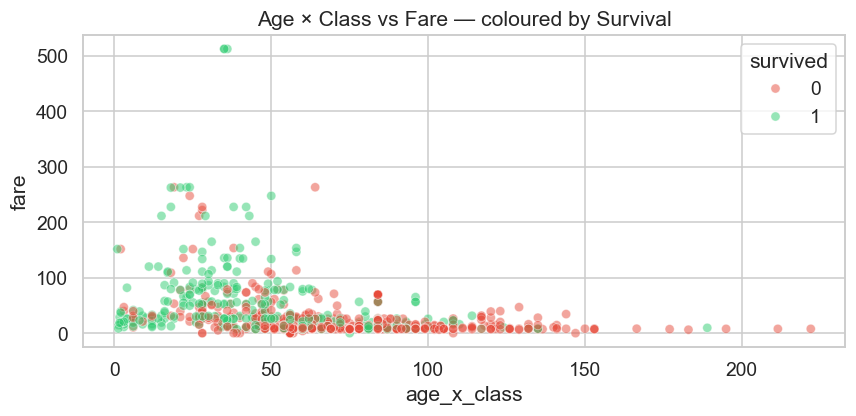

In [28]:
df["age_x_class"] = df["age"] * df["pclass"]

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="age_x_class", y="fare",
                hue="survived", palette={0:"#e74c3c", 1:"#2ecc71"}, alpha=0.5)
plt.title("Age × Class vs Fare — coloured by Survival")
plt.tight_layout()
plt.show()


### 11c. Alone × Class

In [29]:
df["alone_x_class"] = df["is_alone"] * df["pclass"]

print("Survival rate by alone_x_class:")
print(df.groupby("alone_x_class")["survived"].mean().round(3))


Survival rate by alone_x_class:
alone_x_class
0    0.506
1    0.532
2    0.346
3    0.213
Name: survived, dtype: float64


## 12. 🔢 Encoding Categorical Variables

All categorical features must be numeric before feeding into ML models.


In [30]:
# Binary mapping: sex
df["sex_encoded"] = df["sex"].map({"male": 0, "female": 1})
print("sex_encoded:", df["sex_encoded"].value_counts().to_dict())


sex_encoded: {0: 577, 1: 314}


In [31]:
# Binary mapping: adult_male
df["adult_male_encoded"] = df["adult_male"].astype(int)
print("adult_male_encoded:", df["adult_male_encoded"].value_counts().to_dict())


adult_male_encoded: {1: 537, 0: 354}


In [32]:
# One-hot encoding: embarked, age_group, fare_group, family_group, social_status
df_encoded = pd.get_dummies(
    df,
    columns=["embarked", "age_group", "fare_group", "family_group", "social_status"],
    drop_first=False,
    dtype=int
)

new_ohe = [c for c in df_encoded.columns if c not in df.columns]
print("New OHE columns:", new_ohe)


New OHE columns: ['embarked_C', 'embarked_Q', 'embarked_S', 'age_group_Child', 'age_group_Teen', 'age_group_Adult', 'age_group_Senior', 'fare_group_budget', 'fare_group_economy', 'fare_group_comfort', 'fare_group_luxury', 'family_group_alone', 'family_group_large', 'family_group_small', 'social_status_Child', 'social_status_Gentleman', 'social_status_Lady', 'social_status_Mr', 'social_status_Woman']


## 13. 📈 Correlation Analysis — What Predicts Survival?

With all features engineered, let's measure Pearson correlation with the target variable.


In [33]:
numeric_df = df_encoded.select_dtypes(include=[np.number])
surv_corr = (numeric_df.corr()["survived"]
               .drop("survived")
               .sort_values(key=abs, ascending=False))

print("Top 25 features by |r| with survived:")
print(surv_corr.head(25).to_string())


Top 25 features by |r| with survived:
status_encoded         0.606183
adult_male_encoded    -0.557080
is_female              0.543351
sex_encoded            0.543351
social_status_Mr      -0.529242
social_status_Lady     0.412074
pclass                -0.338481
log_fare               0.329862
age_x_class           -0.324559
has_cabin              0.319572
is_first_class         0.285904
family_group_small     0.279855
is_high_fare           0.274981
alone_x_class         -0.273747
social_status_Woman    0.269628
fare                   0.257307
fare_group_luxury      0.233638
fare_group_budget     -0.221610
fare_per_person        0.221600
family_group_alone    -0.203367
is_alone              -0.203367
embarked_C             0.168240
embarked_S            -0.149683
social_status_Child    0.136107
family_group_large    -0.125147


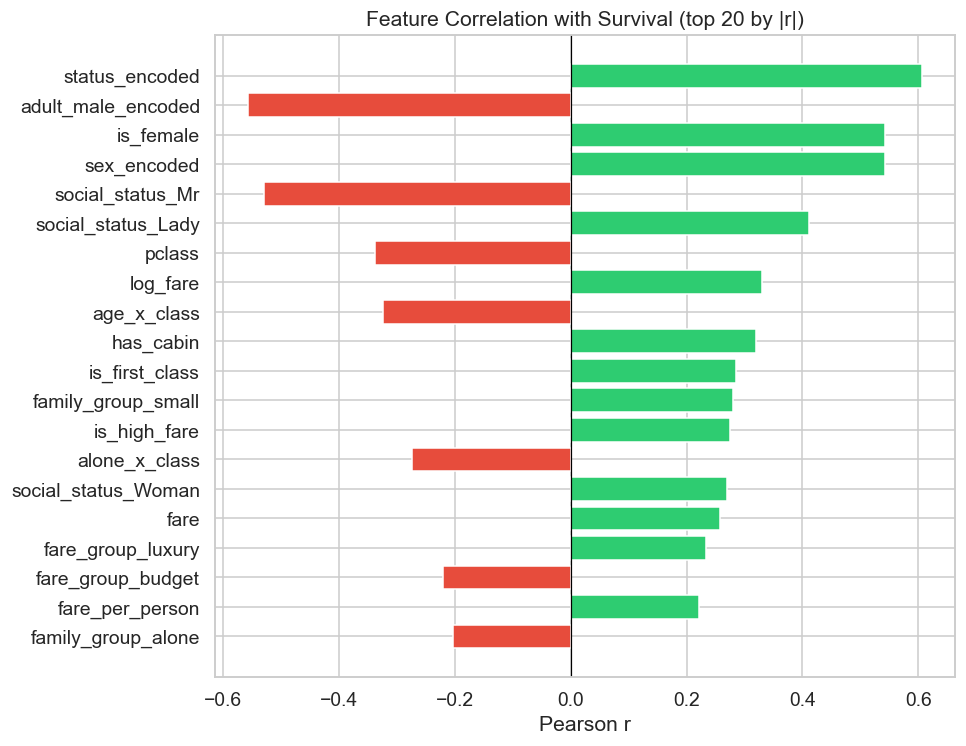

In [34]:
top_corr = surv_corr.head(20)
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in top_corr.values]

plt.figure(figsize=(9, 7))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Survival (top 20 by |r|)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()


In [ ]:
# Heatmap of key engineered features
key_feats = [
    "survived", "pclass", "sex_encoded", "age", "family_size",
    "is_alone", "fare_per_person", "log_fare", "fare_vs_class",
    "has_cabin", "is_child", "is_female", "is_first_class", "is_high_fare",
    "status_encoded", "age_x_class", "alone_x_class"
]

plt.figure(figsize=(13, 10))
corr = df_encoded[key_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Engineered Features")
plt.tight_layout()
plt.show()


## 14. 📋 Final Feature Summary

In [35]:
print(f"Final DataFrame shape: {df_encoded.shape}")
print()
print("All columns:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i:>3}. {col}")


Final DataFrame shape: (891, 44)

All columns:
    1. survived
    2. pclass
    3. sex
    4. age
    5. sibsp
    6. parch
    7. fare
    8. who
    9. adult_male
   10. alone
   11. has_cabin
   12. family_size
   13. is_alone
   14. status_encoded
   15. is_child
   16. is_female
   17. is_first_class
   18. is_high_fare
   19. fare_per_person
   20. log_fare
   21. sex_class
   22. age_x_class
   23. alone_x_class
   24. sex_encoded
   25. adult_male_encoded
   26. embarked_C
   27. embarked_Q
   28. embarked_S
   29. age_group_Child
   30. age_group_Teen
   31. age_group_Adult
   32. age_group_Senior
   33. fare_group_budget
   34. fare_group_economy
   35. fare_group_comfort
   36. fare_group_luxury
   37. family_group_alone
   38. family_group_large
   39. family_group_small
   40. social_status_Child
   41. social_status_Gentleman
   42. social_status_Lady
   43. social_status_Mr
   44. social_status_Woman


In [36]:
df_encoded.head(5)


,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,alone,...,fare_group_comfort,fare_group_luxury,family_group_alone,family_group_large,family_group_small,social_status_Child,social_status_Gentleman,social_status_Lady,social_status_Mr,social_status_Woman
0,0,3,male,22.0,1,0,7.2500,man,True,False,...,0,0,0,0,1,0,0,0,1,0
1,1,1,female,38.0,1,0,71.2833,woman,False,False,...,0,1,0,0,1,0,0,1,0,0
2,1,3,female,26.0,0,0,7.9250,woman,False,True,...,0,0,1,0,0,0,0,0,0,1
3,1,1,female,35.0,1,0,53.1000,woman,False,False,...,0,1,0,0,1,0,0,1,0,0
4,0,3,male,35.0,0,0,8.0500,man,True,True,...,0,0,1,0,0,0,0,0,1,0


---

## ✅ Summary of All Feature Engineering Techniques

| Feature | Type | Technique |
|---------|------|-----------|
| `family_size` | Numeric | Domain knowledge (sibsp + parch + 1) |
| `is_alone` | Binary | Logical / threshold |
| `family_group` | Categorical | Rule-based grouping |
| `has_cabin` | Binary | Missing-as-information |
| `social_status` | Categorical | Rule-based from who + sex + pclass |
| `status_encoded` | Numeric | Ordinal / target-informed encoding |
| `age_group` | Categorical | Uniform binning |
| `fare_group` | Categorical | Quantile binning (equal-frequency) |
| `is_child` | Binary | Rule-based threshold |
| `is_female` | Binary | Binary mapping |
| `is_first_class` | Binary | Rule-based threshold |
| `is_high_fare` | Binary | Median threshold |
| `fare_per_person` | Numeric | Ratio normalisation |
| `log_fare` | Numeric | Log transformation (skew correction) |
| `fare_vs_class` | Numeric | Group-relative ratio |
| `sex_class` | Categorical | Interaction feature (text) |
| `age_x_class` | Numeric | Multiplicative interaction |
| `alone_x_class` | Numeric | Multiplicative interaction |
| `sex_encoded` | Numeric | Binary mapping |
| `embarked_*` | Numeric | One-hot encoding |
| `age_group_*` | Numeric | One-hot encoding |
| `fare_group_*` | Numeric | One-hot encoding |
| `social_status_*` | Numeric | One-hot encoding |

> **Next step:** Drop `sex`, `who`, `social_status`, `sex_class`, `fare_group`, `age_group`, `family_group` (string versions) and pass the numeric columns into `sklearn`'s `RandomForestClassifier` or `LogisticRegression` to compare engineered vs raw features.
